In [1]:
'Script to investigate the association between cortical atrophy [in Huntingtons disease] and functional/structural connectivity'
'Original paper: Network-based atrophy modeling in the common epilepsies: A worldwide ENIGMA study'
'Enigma docs https://enigma-toolbox.readthedocs.io/en/latest/pages/07.epicenter/index.html'
'Original Code: https://github.com/MICA-MNI/ENIGMA/blob/master/docs/pages/07.epicenter/index.rst'


'Original Code: https://github.com/MICA-MNI/ENIGMA/blob/master/docs/pages/07.epicenter/index.rst'

In [2]:
import numpy as np
import pandas as pd
from enigmatoolbox.datasets import load_sc, load_fc
from nilearn import plotting
from enigmatoolbox.permutation_testing import spin_test
from enigmatoolbox.utils.parcellation import parcel_to_surface
from enigmatoolbox.plotting import plot_cortical
from enigmatoolbox.plotting import plot_subcortical
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.stats.multitest as multi


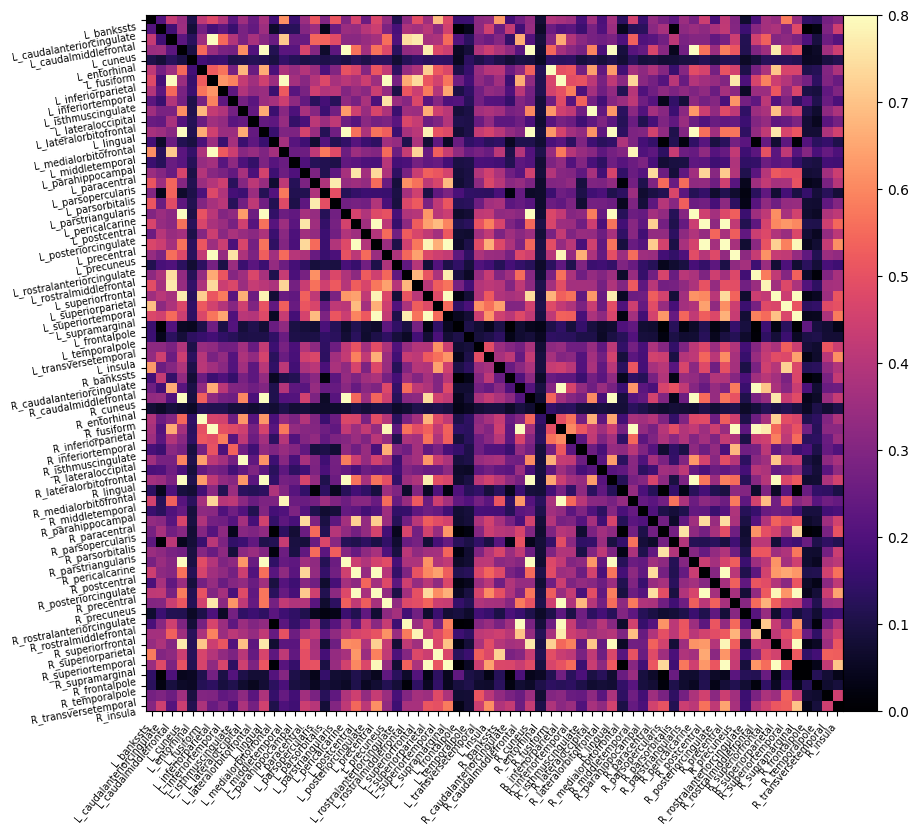

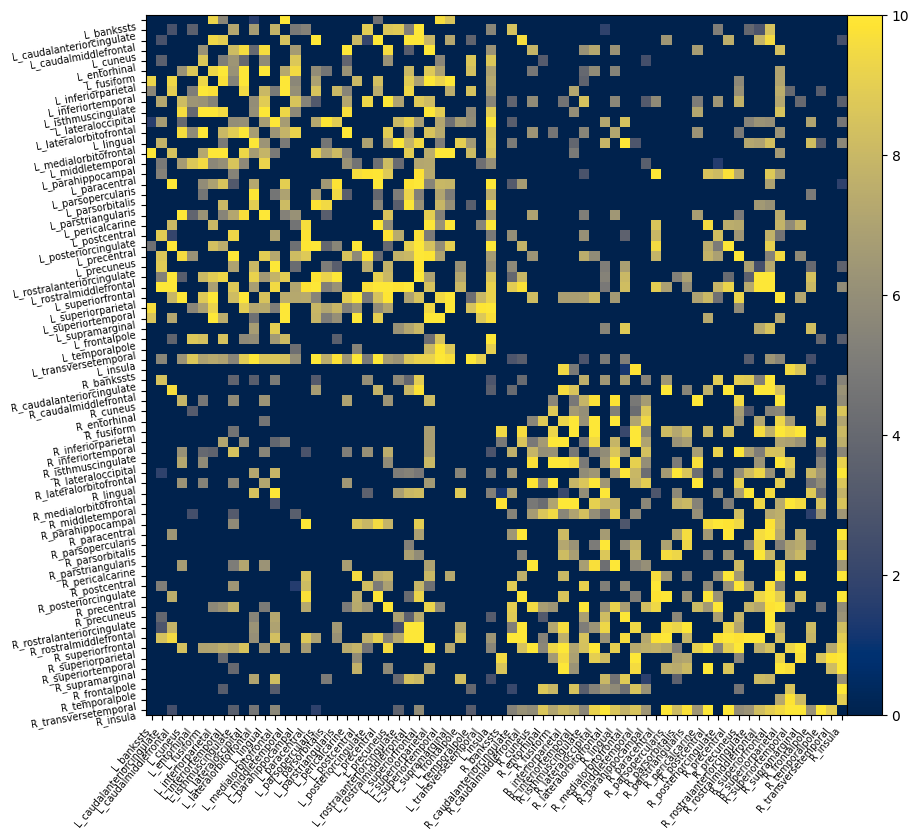

In [3]:
# Load cortico-cortical functional connectivity data
fc_ctx, fc_ctx_labels, _, _ = load_fc()
# Load cortico-cortical structural connectivity data
sc_ctx, sc_ctx_labels, _, _ = load_sc()

# Plot cortico-cortical connectivity matrices
fc_plot = plotting.plot_matrix(fc_ctx, figure=(9, 9), labels=fc_ctx_labels, vmax=0.8, vmin=0, cmap='magma')
output_directory = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/figures"
output_file = os.path.join(output_directory, "cx_fc_plot_hcp.png")
fc_plot.figure.savefig(output_file)

sc_plot = plotting.plot_matrix(sc_ctx, figure=(9, 9), labels=sc_ctx_labels, vmax=10, vmin=0, cmap='cividis')
output_file = os.path.join(output_directory, "cx_sc_plot_hcp.png")
sc_plot.figure.savefig(output_file)

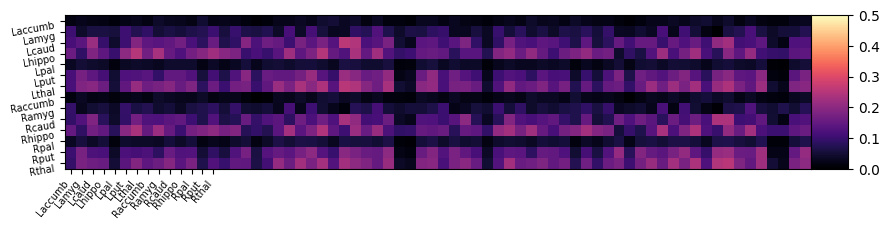

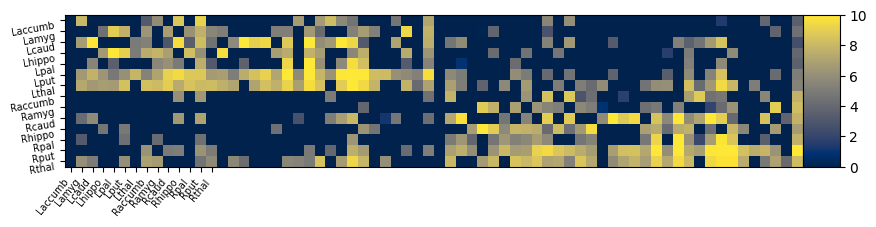

In [4]:
#SUBCORTICAL 

# Load subcortico-cortical functional connectivity data
_, _, fc_sctx, fc_sctx_labels = load_fc()

# Load subcortico-cortical structural connectivity data
_, _, sc_sctx, sc_sctx_labels = load_sc()

# Plot subcortico-cortical connectivity matrices
fc_plot = plotting.plot_matrix(fc_sctx, figure=(9, 9), labels=fc_sctx_labels, vmax=0.5, vmin=0, cmap='magma')
output_directory = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/figures"
output_file = os.path.join(output_directory, "scx_fc_plot_hcp.png")
fc_plot.figure.savefig(output_file)

sc_plot = plotting.plot_matrix(sc_sctx, figure=(9, 9), labels=sc_sctx_labels, vmax=10, vmin=0, cmap='cividis')
output_file = os.path.join(output_directory, "scx_sc_plot_hcp.png")
sc_plot.figure.savefig(output_file)

In [ ]:
#### MIND - NODE TRACK #####  

# Load node DK maps
disorders = ['node_track']
d = {}

# Read the CSV file
data=pd.read_csv('/Users/charlie/Desktop/my_projects/neurotransmitter/github/data/cohens_d_right_transp.csv', header = None)
# Remove the first row
data = data.iloc[1:]
# Remove the first two columns
data = data.iloc[:, 1:]
# Reset the index
data = data.reset_index(drop=True)
CT_d=data.squeeze()
CT_d.name = 'd_icv'
CT_d = CT_d.astype(float)


# Identify cortical epicenters (from functional connectivity)
fc_ctx_track = []
fc_ctx_track_p = []

for seed in range(fc_ctx.shape[0]):
    seed_con = fc_ctx[:, seed]
    fc_ctx_track = np.append(fc_ctx_track, np.corrcoef(seed_con, CT_d)[0, 1])
    fc_ctx_track_p = np.append(fc_ctx_track_p,
                             spin_test(seed_con, CT_d, surface_name='fsa5', parcellation_name='aparc',type='pearson', n_rot=1000, null_dist=False))
                                        #type='pearson', n_rot=10, null_dist=False))

# Identify cortical epicenters (from structural connectivity)
sc_ctx_track = []
sc_ctx_track_p = []
for seed in range(sc_ctx.shape[0]):
    seed_con = sc_ctx[:, seed]
    sc_ctx_track = np.append(sc_ctx_track, np.corrcoef(seed_con, CT_d)[0, 1])
    sc_ctx_track_p = np.append(sc_ctx_track_p,
                             spin_test(seed_con, CT_d, surface_name='fsa5', parcellation_name='aparc', type='pearson', n_rot=1000, null_dist=False))
                                    #type='pearson', n_rot=10, null_dist=False))
        

#Perform FDR correction
fc_ctx_track_p = multi.multipletests(fc_ctx_track_p, method='fdr_bh')[1]

# Selecting only regions with FDR corrected p < 0.05 (functional epicenters)
fc_ctx_track_p_sig = np.zeros_like(fc_ctx_track_p)

fc_ctx_track_p_sig[np.argwhere(fc_ctx_track_p < 0.05)] = fc_ctx_track[np.argwhere(fc_ctx_track_p < 0.05)]

#The figure represents the correlation coefficients of the regions that are significant at a p<0.05
#note that I have readjusted the color range otherwise from 0.5 to 0.7 some coefficients were left out
plot_cortical(array_name=parcel_to_surface(fc_ctx_track_p_sig, 'aparc_fsa5'), surface_name="fsa5", size=(8000, 4000),
              cmap='RdBu',screenshot=True, color_bar=True, 
              color_range=(-0.7, 0.7), 
              filename="/Users/charlie/Desktop/my_projects/neurotransmitter/github/figures/fc_ctx_track_node.png")

#Command below to visualise 3D image
#plot_cortical(array_name=parcel_to_surface(fc_ctx_track_p_sig, 'aparc_fsa5'), surface_name="fsa5", size=(800, 400),
              #cmap='GyRd_r', color_bar=True, color_range=(-0.5, 0.5))

    
    
    

regions = [
    'lh_bankssts_thickness', 'lh_caudalanteriorcingulate_thickness', 'lh_caudalmiddlefrontal_thickness',
    'lh_cuneus_thickness', 'lh_entorhinal_thickness', 'lh_fusiform_thickness', 'lh_inferiorparietal_thickness',
    'lh_inferiortemporal_thickness', 'lh_isthmuscingulate_thickness', 'lh_lateraloccipital_thickness',
    'lh_lateralorbitofrontal_thickness', 'lh_lingual_thickness', 'lh_medialorbitofrontal_thickness',
    'lh_middletemporal_thickness', 'lh_parahippocampal_thickness', 'lh_paracentral_thickness',
    'lh_parsopercularis_thickness', 'lh_parsorbitalis_thickness', 'lh_parstriangularis_thickness',
    'lh_pericalcarine_thickness', 'lh_postcentral_thickness', 'lh_posteriorcingulate_thickness',
    'lh_precentral_thickness', 'lh_precuneus_thickness', 'lh_rostralanteriorcingulate_thickness',
    'lh_rostralmiddlefrontal_thickness', 'lh_superiorfrontal_thickness', 'lh_superiorparietal_thickness',
    'lh_superiortemporal_thickness', 'lh_supramarginal_thickness', 'lh_frontalpole_thickness',
    'lh_temporalpole_thickness', 'lh_transversetemporal_thickness', 'lh_insula_thickness',
    'rh_bankssts_thickness', 'rh_caudalanteriorcingulate_thickness', 'rh_caudalmiddlefrontal_thickness',
    'rh_cuneus_thickness', 'rh_entorhinal_thickness', 'rh_fusiform_thickness', 'rh_inferiorparietal_thickness',
    'rh_inferiortemporal_thickness', 'rh_isthmuscingulate_thickness', 'rh_lateraloccipital_thickness',
    'rh_lateralorbitofrontal_thickness', 'rh_lingual_thickness', 'rh_medialorbitofrontal_thickness',
    'rh_middletemporal_thickness', 'rh_parahippocampal_thickness', 'rh_paracentral_thickness',
    'rh_parsopercularis_thickness', 'rh_parsorbitalis_thickness', 'rh_parstriangularis_thickness',
    'rh_pericalcarine_thickness', 'rh_postcentral_thickness', 'rh_posteriorcingulate_thickness',
    'rh_precentral_thickness', 'rh_precuneus_thickness', 'rh_rostralanteriorcingulate_thickness',
    'rh_rostralmiddlefrontal_thickness', 'rh_superiorfrontal_thickness', 'rh_superiorparietal_thickness',
    'rh_superiortemporal_thickness', 'rh_supramarginal_thickness', 'rh_frontalpole_thickness',
    'rh_temporalpole_thickness', 'rh_transversetemporal_thickness', 'rh_insula_thickness'
]



##Functional connectivity 

# Combine labels and P values
combined_data = np.column_stack((regions, fc_ctx_track_p))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
# Specify the file path
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/fc_ctx_track_node_p_fdr.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')

# Combine labels and correlation coefficients
combined_data = np.column_stack((regions, fc_ctx_track))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
# Specify the file path
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/fc_ctx_track_node_coefficients.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')


##Structural connectivity
    
# Selecting only regions with p < 0.05 (structural epicenters)

sc_ctx_track_p = multi.multipletests(sc_ctx_track_p, method='fdr_bh')[1]
sc_ctx_track_p_sig = np.zeros_like(sc_ctx_track_p)
sc_ctx_track_p_sig[np.argwhere(sc_ctx_track_p < 0.05)] = sc_ctx_track[np.argwhere(sc_ctx_track_p < 0.05)]
plot_cortical(array_name=parcel_to_surface(sc_ctx_track_p_sig, 'aparc_fsa5'), surface_name="fsa5", size=(8000, 4000),
              cmap='RdBu', color_bar=True, color_range=(-0.7, 0.7),screenshot=True, filename="/Users/charlie/Desktop/my_projects/neurotransmitter/github/figures/sc_ctx_track_node.png" )

combined_data = np.column_stack((regions, sc_ctx_track_p))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
# Specify the file path
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/sc_ctx_track_node_p_fdr.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')

# Combine labels and correlation coefficients
combined_data = np.column_stack((regions, fc_ctx_track))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
# Specify the file path
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/sc_ctx_track_node_coefficients.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')












# SUBCORTICAL TRACK

# Identify subcortical epicenters (from functional connectivity)
fc_sctx_track = []
fc_sctx_track_p = []
for seed in range(fc_sctx.shape[0]):
    seed_con = fc_sctx[seed, :]
    fc_sctx_track = np.append(fc_sctx_track, np.corrcoef(seed_con, CT_d)[0, 1])
    fc_sctx_track_p = np.append(fc_sctx_track_p,
                              spin_test(seed_con, CT_d, surface_name='fsa5', n_rot=1000))
                              #spin_test(seed_con, CT_d, surface_name='fsa5', n_rot=10))
    
    
# Identify subcortical epicenters (from structural connectivity)
sc_sctx_track = []
sc_sctx_track_p = []
for seed in range(sc_sctx.shape[0]):
    seed_con = sc_sctx[seed, :]
    sc_sctx_track = np.append(sc_sctx_track, np.corrcoef(seed_con, CT_d)[0, 1])
    sc_sctx_track_p = np.append(sc_sctx_track_p,
                            spin_test(seed_con, CT_d, surface_name='fsa5', n_rot=1000))
                            #spin_test(seed_con, CT_d, surface_name='fsa5', n_rot=10))


    
# Project the results on the surface brain
# Selecting only regions with p < 0.05 (functional epicenters)
fc_sctx_track_p = multi.multipletests(fc_sctx_track_p, method='fdr_bh')[1]
fc_sctx_track_p_sig = np.zeros_like(fc_sctx_track_p)
fc_sctx_track_p_sig[np.argwhere(fc_sctx_track_p < 0.05)] = fc_sctx_track[np.argwhere(fc_sctx_track_p < 0.05)]
plot_subcortical(fc_sctx_track_p_sig, ventricles=False, size=(8000, 4000),
                 cmap='RdBu', color_bar=True, color_range=(-0.7, 0.7), screenshot=True, filename="/Users/charlie/Desktop/my_projects/neurotransmitter/github/figures/fc_sctx_track_node.png")

# Save the array to the text file
# Labels for the regions
regions = ['Laccumb', 'Lamyg', 'Lcaud', 'Lhippo', 'Lpal', 'Lput', 'Lthal',
           'Raccumb', 'Ramyg', 'Rcaud', 'Rhippo', 'Rpal', 'Rput', 'Rthal']
combined_data = np.column_stack((regions, fc_sctx_track_p))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/fc_sctx_track_node_p_fdr.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')

# Combine labels and correlation coefficients
combined_data = np.column_stack((regions, fc_sctx_track))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
# Specify the file path
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/fc_sctx_track_node_coefficients.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')





# Selecting only regions with p < 0.05 (structural epicenters)
sc_sctx_track_p = multi.multipletests(sc_sctx_track_p, method='fdr_bh')[1]
sc_sctx_track_p_sig = np.zeros_like(sc_sctx_track_p)
sc_sctx_track_p_sig[np.argwhere(sc_sctx_track_p < 0.05)] = sc_sctx_track[np.argwhere(sc_sctx_track_p < 0.05)]


plot_subcortical(sc_sctx_track_p_sig, ventricles=False, size=(8000, 4000),
                 cmap='RdBu', color_bar=True, color_range=(-0.7, 0.7), screenshot=True, filename="/Users/charlie/Desktop/my_projects/neurotransmitter/github/figures/sc_sctx_track_node.png")

combined_data = np.column_stack((regions, sc_sctx_track_p))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/sc_sctx_track_node_p_fdr.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')

# Combine labels and correlation coefficients
combined_data = np.column_stack((regions, sc_sctx_track))
combined_data = combined_data[combined_data[:, 1].astype(float).argsort()][::-1]
# Specify the file path
output_file = "/Users/charlie/Desktop/my_projects/neurotransmitter/github/results/sc_sctx_track_node_coefficients.txt"
# Save the combined data to the text file
np.savetxt(output_file, combined_data, fmt='%s')


permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 

permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 

permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 